In [1]:
import pickle
from pathlib import Path
import polars as pl
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.figsize': (14, 8)
})

In [2]:
#import os
#os.chdir("./AWS_theDiceGame")
#class CloudscapeDataset:
#    pass
#print(os.getcwd())

## SECCIÓN 1: CARGA DE DATOS Y GRAFO MAESTRO

In [3]:
class CloudscapeDataset:
    pass

BASE_DIR = Path(".")
BUNDLE_PATH = BASE_DIR / "output_analytics" / "cloudscape_pipeline_bundle.pkl"

with open(BUNDLE_PATH, "rb") as f:
    bundle = pickle.load(f)

df_services_master = bundle["df_services_master"]
G_cooc_master = bundle["G_cooc_master"]

print(f"Servicios: {G_cooc_master.number_of_nodes()}")
print(f"Aristas: {G_cooc_master.number_of_edges()}")
print(f"Densidad: {nx.density(G_cooc_master):.3f}\n")

Servicios: 78
Aristas: 491
Densidad: 0.164



## SECCIÓN 2: ENCONTRAR ORDEN PREFERIDO

In [4]:
pagerank = nx.pagerank(G_cooc_master, weight='weight')
degree_centrality = nx.degree_centrality(G_cooc_master)
betweenness = nx.betweenness_centrality(G_cooc_master, weight='weight')
closeness = nx.closeness_centrality(G_cooc_master, distance='weight')

try:
    eigenvector = nx.eigenvector_centrality(G_cooc_master, weight='weight', max_iter=1000)
except:
    eigenvector = nx.eigenvector_centrality_numpy(G_cooc_master, weight='weight')

centralidad_data = []
for service in G_cooc_master.nodes():
    row = df_services_master.filter(pl.col('service') == service)
    num_archs = row['num_architectures'].first() if row.height > 0 else 0

    centralidad_data.append({
        'service': service,
        'num_architectures': num_archs,
        'degree': G_cooc_master.degree(service),
        'pagerank': pagerank.get(service, 0),
        'degree_centrality': degree_centrality.get(service, 0),
        'betweenness': betweenness.get(service, 0),
        'closeness': closeness.get(service, 0),
        'eigenvector': eigenvector.get(service, 0)
    })

df_centralidad = pl.DataFrame(centralidad_data)

for col in ['pagerank', 'degree_centrality', 'betweenness', 'closeness', 'eigenvector']:
    max_val = df_centralidad[col].max()
    if max_val > 0:
        df_centralidad = df_centralidad.with_columns((pl.col(col) / max_val).alias(col))

df_centralidad = df_centralidad.with_columns(
    (0.30 * pl.col('pagerank') +
     0.25 * pl.col('degree_centrality') +
     0.20 * pl.col('betweenness') +
     0.15 * pl.col('eigenvector') +
     0.10 * pl.col('closeness')).alias('centralidad_score')
).sort('centralidad_score', descending=True)

print("TOP 15 POR CENTRALIDAD:")
print(df_centralidad.select(['service', 'num_architectures', 'degree', 'centralidad_score']).head(15))

alto = len(df_centralidad.filter(pl.col('centralidad_score') > 0.5))
medio = len(df_centralidad.filter((pl.col('centralidad_score') > 0.3) & (pl.col('centralidad_score') <= 0.5)))
esp = len(df_centralidad.filter(pl.col('centralidad_score') <= 0.3))

print(f"\nAlto: {alto}, Medio: {medio}, Especializado: {esp}\n")

TOP 15 POR CENTRALIDAD:
shape: (15, 4)
┌────────────┬───────────────────┬────────┬───────────────────┐
│ service    ┆ num_architectures ┆ degree ┆ centralidad_score │
│ ---        ┆ ---               ┆ ---    ┆ ---               │
│ str        ┆ i64               ┆ i64    ┆ f64               │
╞════════════╪═══════════════════╪════════╪═══════════════════╡
│ S3         ┆ 231               ┆ 67     ┆ 1.0               │
│ Lambda     ┆ 205               ┆ 62     ┆ 0.837481          │
│ EC2        ┆ 131               ┆ 49     ┆ 0.597545          │
│ DynamoDB   ┆ 114               ┆ 45     ┆ 0.584912          │
│ ApiGateway ┆ 91                ┆ 38     ┆ 0.479511          │
│ …          ┆ …                 ┆ …      ┆ …                 │
│ SageMaker  ┆ 39                ┆ 26     ┆ 0.294461          │
│ Athena     ┆ 42                ┆ 24     ┆ 0.282564          │
│ SNS        ┆ 46                ┆ 21     ┆ 0.264696          │
│ Aurora     ┆ 37                ┆ 24     ┆ 0.26              │
│

## SECCIÓN 3: ANÁLISIS SEGÚN CENTRALIDAD

In [5]:
conectividad_data = []
for service in G_cooc_master.nodes():
    vecinos = list(G_cooc_master.neighbors(service))
    num_vecinos = len(vecinos)
    total_otros = G_cooc_master.number_of_nodes() - 1
    ratio_compat = num_vecinos / total_otros if total_otros > 0 else 0

    conectividad_data.append({
        'service': service,
        'num_conexiones': num_vecinos,
        'ratio_compatibilidad': ratio_compat,
        'vecinos': ', '.join(sorted(vecinos)[:5]) + ('...' if len(vecinos) > 5 else '')
    })

df_conectividad = pl.DataFrame(conectividad_data).sort('num_conexiones', descending=True)

print("\nTOP 10 MÁS CONECTADOS:")
print(df_conectividad.select(['service', 'num_conexiones', 'ratio_compatibilidad']).head(10))

print("\nTOP 10 MENOS CONECTADOS:")
print(df_conectividad.select(['service', 'num_conexiones', 'ratio_compatibilidad']).tail(10))


TOP 10 MÁS CONECTADOS:
shape: (10, 3)
┌───────────────┬────────────────┬──────────────────────┐
│ service       ┆ num_conexiones ┆ ratio_compatibilidad │
│ ---           ┆ ---            ┆ ---                  │
│ str           ┆ i64            ┆ f64                  │
╞═══════════════╪════════════════╪══════════════════════╡
│ S3            ┆ 67             ┆ 0.87013              │
│ Lambda        ┆ 62             ┆ 0.805195             │
│ EC2           ┆ 49             ┆ 0.636364             │
│ DynamoDB      ┆ 45             ┆ 0.584416             │
│ ApiGateway    ┆ 38             ┆ 0.493506             │
│ RDS           ┆ 35             ┆ 0.454545             │
│ EKS           ┆ 31             ┆ 0.402597             │
│ SQS           ┆ 29             ┆ 0.376623             │
│ StepFunctions ┆ 27             ┆ 0.350649             │
│ SageMaker     ┆ 26             ┆ 0.337662             │
└───────────────┴────────────────┴──────────────────────┘

TOP 10 MENOS CONECTADOS:
shape: 

## SECCIÓN 4: GRAFO

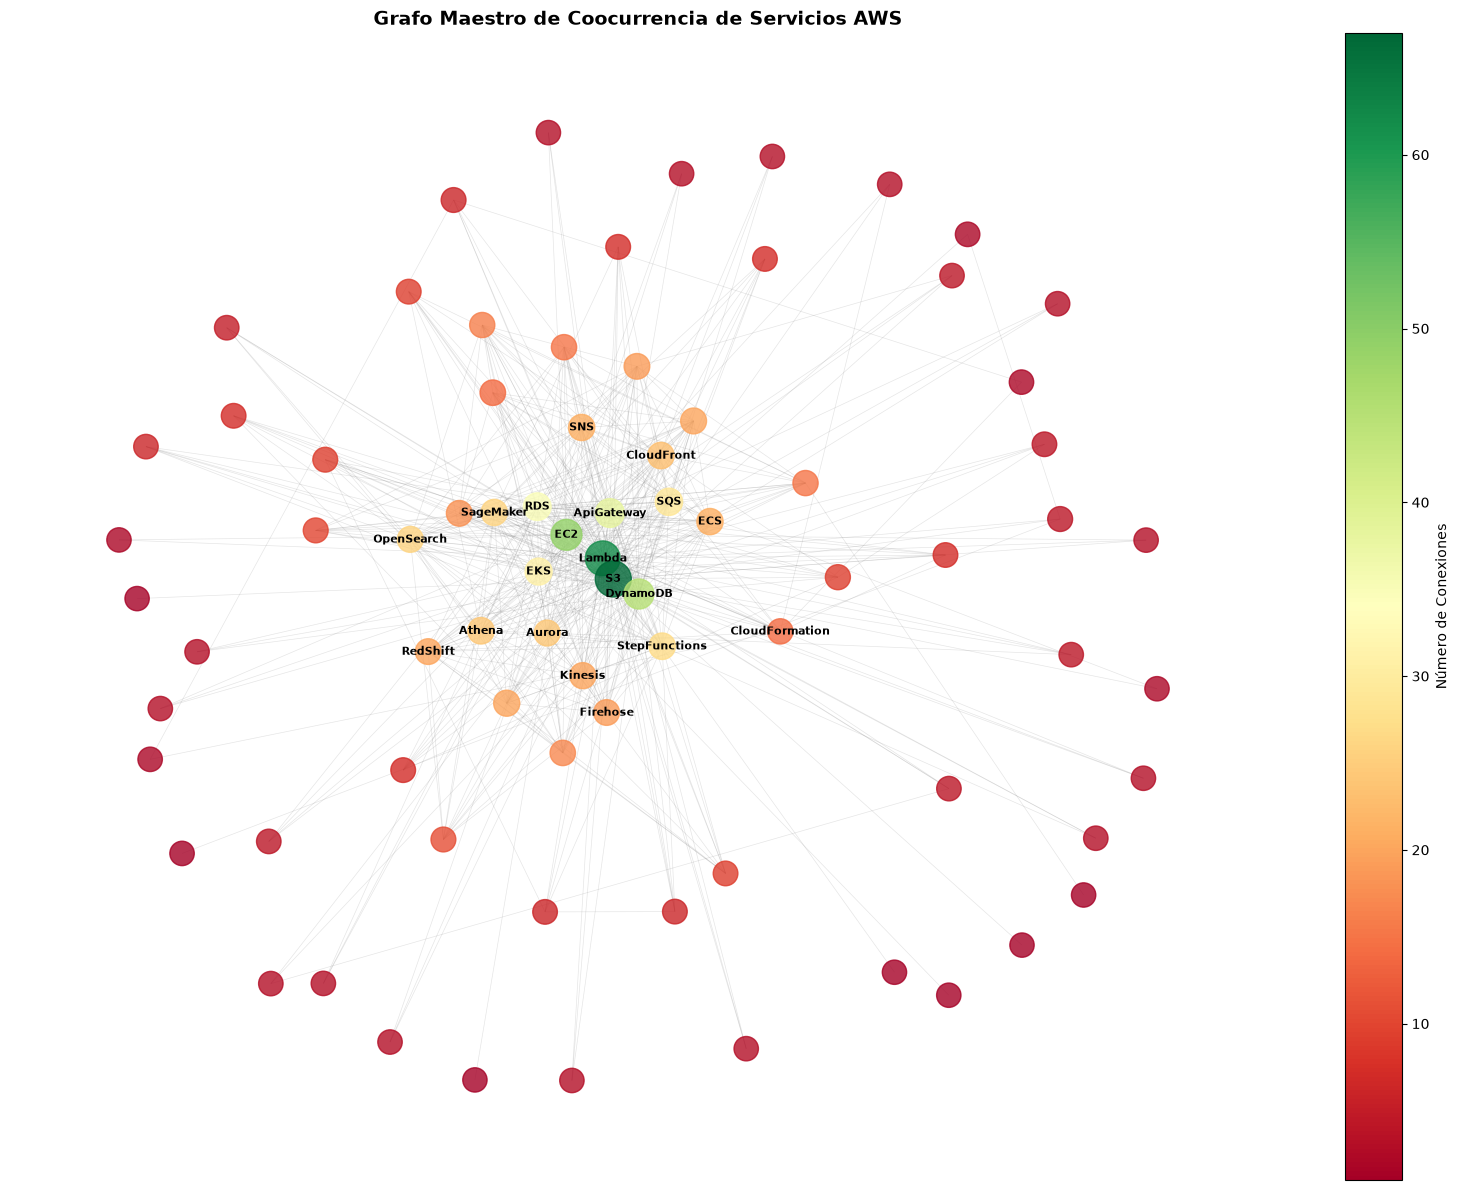

In [6]:
pos = nx.spring_layout(G_cooc_master, k=2, iterations=50, seed=42, weight='weight')
fig, ax = plt.subplots(figsize=(16, 12))

node_sizes = [3000 * pagerank.get(node, 0.01) + 300 for node in G_cooc_master.nodes()]
degree_colors = [G_cooc_master.degree(node) for node in G_cooc_master.nodes()]

nx.draw_networkx_edges(G_cooc_master, pos, ax=ax, alpha=0.2, width=0.5, edge_color='gray')
nx.draw_networkx_nodes(G_cooc_master, pos, node_size=node_sizes, node_color=degree_colors,
                       cmap=plt.cm.RdYlGn, ax=ax, alpha=0.8)

top_services = df_centralidad.select('service').head(20).to_series().to_list()
labels = {node: node if node in top_services else '' for node in G_cooc_master.nodes()}
nx.draw_networkx_labels(G_cooc_master, pos, labels, font_size=8, font_weight='bold', ax=ax)

ax.set_title('Grafo Maestro de Coocurrencia de Servicios AWS', fontsize=14, fontweight='bold')
ax.axis('off')

sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlGn, norm=plt.Normalize(vmin=min(degree_colors), vmax=max(degree_colors)))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Número de Conexiones')

plt.tight_layout()
plt.savefig('grafo_maestro_centralidad.png', dpi=300, bbox_inches='tight')
plt.show()

## SECCIÓN 5: ORDEN PREFERIDO PARA DADOS

In [7]:
df_centralidad = df_centralidad.with_columns(
    pl.when(pl.col('centralidad_score') > 0.5).then(pl.lit('Fundamental'))
    .when(pl.col('centralidad_score') > 0.3).then(pl.lit('Integrador'))
    .otherwise(pl.lit('Especializado')).alias('nivel')
)

for nivel in ['Fundamental', 'Integrador', 'Especializado']:
    servicios = df_centralidad.filter(pl.col('nivel') == nivel).sort('centralidad_score', descending=True)
    print(f"\n{nivel.upper()} ({len(servicios)} servicios):")
    print("-" * 60)
    for row in servicios.head(10).iter_rows(named=True):
        print(f"  {row['service']:20s} | Score: {row['centralidad_score']:.3f} | Conexiones: {row['degree']}")
    if len(servicios) > 10:
        print(f"  ... y {len(servicios) - 10} más")


FUNDAMENTAL (4 servicios):
------------------------------------------------------------
  S3                   | Score: 1.000 | Conexiones: 67
  Lambda               | Score: 0.837 | Conexiones: 62
  EC2                  | Score: 0.598 | Conexiones: 49
  DynamoDB             | Score: 0.585 | Conexiones: 45

INTEGRADOR (6 servicios):
------------------------------------------------------------
  ApiGateway           | Score: 0.480 | Conexiones: 38
  RDS                  | Score: 0.428 | Conexiones: 35
  EKS                  | Score: 0.374 | Conexiones: 31
  SQS                  | Score: 0.350 | Conexiones: 29
  StepFunctions        | Score: 0.343 | Conexiones: 27
  OpenSearch           | Score: 0.310 | Conexiones: 26

ESPECIALIZADO (68 servicios):
------------------------------------------------------------
  SageMaker            | Score: 0.294 | Conexiones: 26
  Athena               | Score: 0.283 | Conexiones: 24
  SNS                  | Score: 0.265 | Conexiones: 21
  Aurora        

## SECCIÓN 6: Guardar

In [8]:
df_centralidad.write_csv('centralidad_servicios.csv')
print("centralidad_servicios.csv")

df_conectividad.write_csv('conectividad_servicios.csv')
print("conectividad_servicios.csv")

df_orden = df_centralidad.select(['service', 'centralidad_score', 'nivel', 'degree'])
df_orden.write_csv('orden_preferido_servicios.csv')
print("orden_preferido_servicios.csv")

centralidad_servicios.csv
conectividad_servicios.csv
orden_preferido_servicios.csv


## SECCIÓN 7: VALIDACIÓN

In [9]:
fundamental = df_centralidad.filter(pl.col('centralidad_score') > 0.5)['service'].to_list()
integrador = df_centralidad.filter((pl.col('centralidad_score') > 0.3) & (pl.col('centralidad_score') <= 0.5))['service'].to_list()

print("\nFUNDAMENTAL:")
print("-" * 80)

for i, serv1 in enumerate(fundamental):
    for j, serv2 in enumerate(fundamental):
        if i < j:
            tiene_arista = G_cooc_master.has_edge(serv1, serv2)
            estado = "✅" if tiene_arista else "❌"
            print(f"  {serv1:15s} <-> {serv2:15s}  {estado}")

print("\nINTEGRADOR:")
print("-" * 80)

for i, serv1 in enumerate(integrador):
    for j, serv2 in enumerate(integrador):
        if i < j:
            tiene_arista = G_cooc_master.has_edge(serv1, serv2)
            estado = "✅" if tiene_arista else "❌"
            print(f"  {serv1:20s} <-> {serv2:20s}  {estado}")

incomp_fund = sum(1 for i, s1 in enumerate(fundamental)
                  for s2 in fundamental[i+1:]
                  if not G_cooc_master.has_edge(s1, s2))

print(f"\nFUNDAMENTAL: {incomp_fund} incompatibilidades")


FUNDAMENTAL:
--------------------------------------------------------------------------------
  S3              <-> Lambda           ✅
  S3              <-> EC2              ✅
  S3              <-> DynamoDB         ✅
  Lambda          <-> EC2              ✅
  Lambda          <-> DynamoDB         ✅
  EC2             <-> DynamoDB         ✅

INTEGRADOR:
--------------------------------------------------------------------------------
  ApiGateway           <-> RDS                   ✅
  ApiGateway           <-> EKS                   ✅
  ApiGateway           <-> SQS                   ✅
  ApiGateway           <-> StepFunctions         ✅
  ApiGateway           <-> OpenSearch            ✅
  RDS                  <-> EKS                   ✅
  RDS                  <-> SQS                   ✅
  RDS                  <-> StepFunctions         ✅
  RDS                  <-> OpenSearch            ✅
  EKS                  <-> SQS                   ✅
  EKS                  <-> StepFunctions         ❌
  EK

## SECCIÓN 8: CLASIFICAR FUNDAMENTAL

In [10]:
df_services_cat = pl.read_csv(Path(".") / "data" / "services.csv").select(['name', 'aws_product_categories'])
cat_map_raw = {}
for row in df_services_cat.iter_rows(named=True):
    cats = [c.strip() for c in row['aws_product_categories'].split(',')] if row['aws_product_categories'] else []
    cat_map_raw[row['name']] = cats

group_mapping = {
    'Compute': ['Compute'],
    'Storage': ['Storage'],
    'Networking': ['Networking and Content Delivery'],
    'Integration': ['Application Integration'],
    'Analytics': ['Analytics'],
    'Security': ['Security Identity and Compliance'],
    'Management': ['Management and Governance'],
    'IoT': ['IoT'],
    'Media': ['Media Services'],
    'Developer': ['Developer Tools'],
    'Database': ['Database'],
    'ML': ['ML'],
    'Other': []
}

def get_service_category(service):
    cats = cat_map_raw.get(service, [])
    for group, keywords in group_mapping.items():
        for kw in keywords:
            if any(kw in c for c in cats):
                return group
    cap = df_services_master.filter(pl.col('service') == service)['capability'].first()
    return {'compute': 'Compute', 'storage': 'Storage', 'networking': 'Networking', 'integration': 'Integration'}.get(cap, 'Other')

fundamental = df_centralidad.filter(pl.col('centralidad_score') > 0.5)['service'].to_list()

incompatibles_fund = []
for i, s1 in enumerate(fundamental):
    for s2 in fundamental[i + 1:]:
        if not G_cooc_master.has_edge(s1, s2):
            incompatibles_fund.append((s1, s2))



print("\nPares incompatibles:")
for s1, s2 in incompatibles_fund:
    print(f"  ❌ {s1:20s} <-> {s2:20s}")

parejas_forzadas_fund = {}
servicios_ya_emparejados_fund = set()

for s1, s2 in incompatibles_fund:
    if s1 not in servicios_ya_emparejados_fund and s2 not in servicios_ya_emparejados_fund:
        parejas_forzadas_fund[f"{s1}_{s2}"] = [s1, s2]
        servicios_ya_emparejados_fund.add(s1)
        servicios_ya_emparejados_fund.add(s2)

libres_fund = [s for s in fundamental if s not in servicios_ya_emparejados_fund]

tipos_fund = {}
for serv in libres_fund:
    tipo = get_service_category(serv)
    if tipo not in tipos_fund:
        tipos_fund[tipo] = []
    tipos_fund[tipo].append(serv)

print("\nLibres:")
for tipo, servicios in sorted(tipos_fund.items()):
    print(f"  {tipo}: {servicios}")


Pares incompatibles:

Libres:
  Compute: ['Lambda', 'EC2']
  Database: ['DynamoDB']
  Storage: ['S3']


## SECCIÓN 9: CLASIFICAR INTEGRADOR

In [11]:
integrador = df_centralidad.filter((pl.col('centralidad_score') > 0.3) & (pl.col('centralidad_score') <= 0.5))['service'].to_list()

incompatibles = []
for i, s1 in enumerate(integrador):
    for s2 in integrador[i + 1:]:
        if not G_cooc_master.has_edge(s1, s2):
            incompatibles.append((s1, s2))

print("\nPares incompatibles:")
for s1, s2 in incompatibles:
    print(f"  ❌ {s1:20s} <-> {s2:20s}")


parejas_forzadas = {}
servicios_ya_emparejados = set()

for s1, s2 in incompatibles:
    if s1 not in servicios_ya_emparejados and s2 not in servicios_ya_emparejados:
        parejas_forzadas[f"{s1}_{s2}"] = [s1, s2]
        servicios_ya_emparejados.add(s1)
        servicios_ya_emparejados.add(s2)

libres = [s for s in integrador if s not in servicios_ya_emparejados]

tipos_libres = {}
for serv in libres:
    tipo = get_service_category(serv)
    if tipo not in tipos_libres:
        tipos_libres[tipo] = []
    tipos_libres[tipo].append(serv)

print("\nParejas forzadas:")
for s1, s2 in [parejas_forzadas[k] for k in parejas_forzadas]:
    tipo1 = get_service_category(s1)
    tipo2 = get_service_category(s2)
    print(f"  {s1:20s}({tipo1:15s}) + {s2:20s}({tipo2:15s})")

print("\nLibres:")
for tipo, servicios in sorted(tipos_libres.items()):
    print(f"  {tipo}: {servicios}")


Pares incompatibles:
  ❌ EKS                  <-> StepFunctions       
  ❌ SQS                  <-> OpenSearch          

Parejas forzadas:
  EKS                 (Compute        ) + StepFunctions       (Integration    )
  SQS                 (Integration    ) + OpenSearch          (Analytics      )

Libres:
  Database: ['RDS']
  Networking: ['ApiGateway']


## SECCIÓN 10: AGRUPAR INTEGRADOR MAX 3


In [12]:
max_por_dado = 3
dados_final = []

parejas_forzadas = {}
servicios_ya_emparejados = set()

for s1, s2 in incompatibles:
    if s1 not in servicios_ya_emparejados and s2 not in servicios_ya_emparejados:
        parejas_forzadas[f"{s1}_{s2}"] = [s1, s2]
        servicios_ya_emparejados.add(s1)
        servicios_ya_emparejados.add(s2)

libres = [s for s in integrador if s not in servicios_ya_emparejados]
libres_copy = libres.copy()

for pareja_id, (s1, s2) in enumerate(incompatibles, 1):
    tipo_s1 = get_service_category(s1)
    tipo_s2 = get_service_category(s2)

    complementos = [l for l in libres_copy if get_service_category(l) in (tipo_s1, tipo_s2)]
    complementos_usados = complementos[:max_por_dado - 2]
    dado_contenido = [s1, s2] + complementos_usados

    print(f"Pareja {pareja_id}: {dado_contenido} | Tipos: {tipo_s1}, {tipo_s2}")
    dados_final.append(dado_contenido)

    for c in complementos_usados:
        libres_copy.remove(c)

print("\nLibres restantes:")
for libre in libres_copy:
    tipo = get_service_category(libre)
    print(f"  {libre} ({tipo})")
    dados_final.append([libre])

print("\nDados:")
for i, dado in enumerate(dados_final, 1):
    tipos_en_dado = [get_service_category(s) for s in dado]
    print(f"  Dato_Integrador_{i}: {dado} | Tipos: {tipos_en_dado}")

print(f"\nTotal: {len(dados_final)} dados")

Pareja 1: ['EKS', 'StepFunctions'] | Tipos: Compute, Integration
Pareja 2: ['SQS', 'OpenSearch'] | Tipos: Integration, Analytics

Libres restantes:
  ApiGateway (Networking)
  RDS (Database)

Dados:
  Dato_Integrador_1: ['EKS', 'StepFunctions'] | Tipos: ['Compute', 'Integration']
  Dato_Integrador_2: ['SQS', 'OpenSearch'] | Tipos: ['Integration', 'Analytics']
  Dato_Integrador_3: ['ApiGateway'] | Tipos: ['Networking']
  Dato_Integrador_4: ['RDS'] | Tipos: ['Database']

Total: 4 dados


## SECCIÓN 11: JUNTAR


In [13]:
def calcular_popularidad(servicios_list):
    total = 0
    for serv in servicios_list:
        row = df_centralidad.filter(pl.col('service') == serv)
        if len(row) > 0:
            total += row['num_architectures'][0]
    return total

fundamental_grupos = tipos_fund
fund_popularidad = {tipo: (servicios, calcular_popularidad(servicios))
                    for tipo, servicios in fundamental_grupos.items()}

print("\nFUNDAMENTAL popularidad:")
for tipo, (servicios, pop) in fund_popularidad.items():
    print(f"  {tipo}: {servicios} (pop: {pop})")

integ_info = []
for i, dado_contenido in enumerate(dados_final, 1):
    tipos_en_dado = list(set([get_service_category(s) for s in dado_contenido]))
    pop = calcular_popularidad(dado_contenido)
    integ_info.append({
        'id': f'Dato_Integrador_{i}',
        'servicios': dado_contenido,
        'tipos': tipos_en_dado,
        'popularidad': pop
    })

print("\nINTEGRADOR popularidad:")
for info in integ_info:
    print(f"  {info['id']}: {info['servicios']} (pop: {info['popularidad']})")


asignaciones = {}

for tipo, (fund_servicios, fund_pop) in fund_popularidad.items():
    integ_mismo_tipo = [info for info in integ_info if tipo in info['tipos']]

    if integ_mismo_tipo:
        integ_mismo_tipo.sort(key=lambda x: x['popularidad'])
        integ_elegido = integ_mismo_tipo[0]

        print(f"\n{tipo}:")
        print(f"  FUNDAMENTAL: {fund_servicios} (pop: {fund_pop})")
        print(f"  INTEGRADOR: {integ_elegido['servicios']} (pop: {integ_elegido['popularidad']})")

        asignaciones[tipo] = {
            'fundamental': fund_servicios,
            'integrador': integ_elegido['servicios'],
            'popularidad_total': fund_pop + integ_elegido['popularidad']
        }
    else:
        print(f"\n{tipo}:")
        print(f"  FUNDAMENTAL: {fund_servicios} (pop: {fund_pop})")
        print(f"  INTEGRADOR: ninguno")

        asignaciones[tipo] = {
            'fundamental': fund_servicios,
            'integrador': [],
            'popularidad_total': fund_pop
        }

asignados = set()
for info in asignaciones.values():
    asignados.update(info['integrador'])

no_asignados = [info for info in integ_info if not any(s in asignados for s in info['servicios'])]


for tipo in sorted(asignaciones.keys()):
    info = asignaciones[tipo]
    contenido = info['fundamental'] + info['integrador']
    print(f"\nDado_{tipo}: {contenido}")

if no_asignados:
    print("\nNo asignados:")
    for info in no_asignados:
        print(f"  {info['id']}: {info['servicios']}")

print(f"\n✅ Total: {len(asignaciones)} + {len(no_asignados)} dados")


FUNDAMENTAL popularidad:
  Storage: ['S3'] (pop: 231)
  Compute: ['Lambda', 'EC2'] (pop: 336)
  Database: ['DynamoDB'] (pop: 114)

INTEGRADOR popularidad:
  Dato_Integrador_1: ['EKS', 'StepFunctions'] (pop: 100)
  Dato_Integrador_2: ['SQS', 'OpenSearch'] (pop: 100)
  Dato_Integrador_3: ['ApiGateway'] (pop: 91)
  Dato_Integrador_4: ['RDS'] (pop: 69)

Storage:
  FUNDAMENTAL: ['S3'] (pop: 231)
  INTEGRADOR: ninguno

Compute:
  FUNDAMENTAL: ['Lambda', 'EC2'] (pop: 336)
  INTEGRADOR: ['EKS', 'StepFunctions'] (pop: 100)

Database:
  FUNDAMENTAL: ['DynamoDB'] (pop: 114)
  INTEGRADOR: ['RDS'] (pop: 69)

Dado_Compute: ['Lambda', 'EC2', 'EKS', 'StepFunctions']

Dado_Database: ['DynamoDB', 'RDS']

Dado_Storage: ['S3']

No asignados:
  Dato_Integrador_2: ['SQS', 'OpenSearch']
  Dato_Integrador_3: ['ApiGateway']

✅ Total: 3 + 2 dados


## SECCIÓN 12: COMPLETAR DADOS

In [14]:
datos_lista = []

for tipo in sorted(asignaciones.keys()):
    info = asignaciones[tipo]
    contenido = info['fundamental'] + info['integrador']
    datos_lista.append({'nombre': f"Dado_{tipo}", 'servicios': contenido, 'tipos': [tipo]})
    print(f"  {f'Dado_{tipo}':30s}: {contenido}")

for info in no_asignados:
    datos_lista.append({'nombre': info['id'], 'servicios': info['servicios'], 'tipos': info['tipos']})
    print(f"  {info['id']:30s}: {info['servicios']}")

print(f"\nTotal: {len(datos_lista)}\n")

def buscar_conflicto_con_dados(servicio, dados_creados):
    for d in dados_creados:
        for serv_en_dado in d['servicios']:
            if not G_cooc_master.has_edge(servicio, serv_en_dado):
                return (d['nombre'], serv_en_dado)
    return None

especializados = df_centralidad.filter(pl.col('nivel') == 'Especializado').sort('num_architectures', descending=True)



descartados = []

for row in especializados.iter_rows(named=True):
    serv_espec = row['service']
    pop = row['num_architectures']

    conflicto = buscar_conflicto_con_dados(serv_espec, datos_lista)
    if conflicto:
        descartados.append(serv_espec)
        continue

    colocado = False
    datos_ordenados = sorted(datos_lista, key=lambda d: len(d['servicios']))

    for dato in datos_ordenados:
        if len(dato['servicios']) < 4:
            dato['servicios'].append(serv_espec)
            print(f"{serv_espec:20s} → {dato['nombre']}")
            colocado = True
            break

    if not colocado:
        descartados.append(serv_espec)
print(f"\n")
for dato in datos_lista:
    print(f"{dato['nombre']}: {dato['servicios']}")

print(f"\ncolocados: {len(especializados) - len(descartados)}")
print(f"DESCARTADOS: {len(descartados)}\n")

  Dado_Compute                  : ['Lambda', 'EC2', 'EKS', 'StepFunctions']
  Dado_Database                 : ['DynamoDB', 'RDS']
  Dado_Storage                  : ['S3']
  Dato_Integrador_2             : ['SQS', 'OpenSearch']
  Dato_Integrador_3             : ['ApiGateway']

Total: 5

SNS                  → Dado_Storage
Athena               → Dato_Integrador_3
SageMaker            → Dado_Database


Dado_Compute: ['Lambda', 'EC2', 'EKS', 'StepFunctions']
Dado_Database: ['DynamoDB', 'RDS', 'SageMaker']
Dado_Storage: ['S3', 'SNS']
Dato_Integrador_2: ['SQS', 'OpenSearch']
Dato_Integrador_3: ['ApiGateway', 'Athena']

colocados: 3
DESCARTADOS: 65



## SECCIÓN 13: 1000

In [15]:
def simular_lanzamiento(datos_lista):
    tirada = []
    for dato in datos_lista:
        servicios = dato['servicios']
        pops = []
        for serv in servicios:
            row = df_centralidad.filter(pl.col('service') == serv)
            if len(row) > 0:
                pops.append(row['num_architectures'][0])
            else:
                pops.append(1)
        pops = np.array(pops)
        probs = pops / pops.sum()
        elegido = np.random.choice(servicios, p=probs)
        tirada.append(elegido)
    return tirada

N_SIMULACIONES = 1000
resultados_tiradas = []
repetidos_totales = 0
incoherencias_totales = 0

for i in range(N_SIMULACIONES):
    tirada = simular_lanzamiento(datos_lista)

    repetidos = len(tirada) - len(set(tirada))
    if repetidos > 0:
        repetidos_totales += 1

    incoherencia_tirada = 0
    for s1, s2 in combinations(tirada, 2):
        if G_cooc_master.has_node(s1) and G_cooc_master.has_node(s2):
            if not G_cooc_master.has_edge(s1, s2):
                incoherencia_tirada += 1

    if incoherencia_tirada > 0:
        incoherencias_totales += 1

    arquitectura_str = " | ".join(sorted(tirada))
    resultados_tiradas.append(arquitectura_str)

print(f"\nTiradas con repetidos: {repetidos_totales} ({repetidos_totales/N_SIMULACIONES*100:.1f}%)")
print(f"Tiradas con incompatibles: {incoherencias_totales} ({incoherencias_totales/N_SIMULACIONES*100:.1f}%)")

resultados_df = pl.DataFrame({'arquitectura': resultados_tiradas})
arch_frecuencia = resultados_df.group_by('arquitectura').len().sort('len', descending=True).rename({'len': 'count'})
arch_frecuencia = arch_frecuencia.with_columns((pl.col('count') / N_SIMULACIONES * 100).alias('porcentaje'))

print(f"\nArquitecturas únicas: {len(arch_frecuencia)}\n")

print("TOP 10:")
print(arch_frecuencia.head(10))

print("\nÚLTIMAS 5:")
print(arch_frecuencia.tail(5))

print("\n")
if incoherencias_totales == 0 and repetidos_totales == 0:
    print("SIN ERRORES")
else:
    print("VALIDACIÓN CON PROBLEMAS")



Tiradas con repetidos: 0 (0.0%)
Tiradas con incompatibles: 0 (0.0%)

Arquitecturas únicas: 85

TOP 10:
shape: (10, 3)
┌─────────────────────────────────┬───────┬────────────┐
│ arquitectura                    ┆ count ┆ porcentaje │
│ ---                             ┆ ---   ┆ ---        │
│ str                             ┆ u32   ┆ f64        │
╞═════════════════════════════════╪═══════╪════════════╡
│ ApiGateway | DynamoDB | Lambda… ┆ 88    ┆ 8.8        │
│ ApiGateway | DynamoDB | EC2 | … ┆ 66    ┆ 6.6        │
│ ApiGateway | Lambda | RDS | S3… ┆ 56    ┆ 5.6        │
│ ApiGateway | DynamoDB | Lambda… ┆ 46    ┆ 4.6        │
│ Athena | DynamoDB | Lambda | S… ┆ 40    ┆ 4.0        │
│ ApiGateway | Lambda | S3 | SQS… ┆ 35    ┆ 3.5        │
│ Athena | Lambda | RDS | S3 | S… ┆ 29    ┆ 2.9        │
│ Athena | DynamoDB | EC2 | S3 |… ┆ 29    ┆ 2.9        │
│ ApiGateway | EC2 | RDS | S3 | … ┆ 27    ┆ 2.7        │
│ ApiGateway | DynamoDB | EKS | … ┆ 26    ┆ 2.6        │
└─────────────────────────

## SECCIÓN 14: DIAGNOSTICO

In [16]:
incomp_encontradas = {}

for i in range(200):
    tirada = simular_lanzamiento(datos_lista)

    for s1, s2 in combinations(tirada, 2):
        if G_cooc_master.has_node(s1) and G_cooc_master.has_node(s2):
            if not G_cooc_master.has_edge(s1, s2):
                pareja = tuple(sorted([s1, s2]))
                incomp_encontradas[pareja] = incomp_encontradas.get(pareja, 0) + 1

print(f"\nParejas incompatibles encontradas: {len(incomp_encontradas)}")


if incomp_encontradas:
    for (s1, s2), count in sorted(incomp_encontradas.items(), key=lambda x: -x[1]):
        tipo1 = get_service_category(s1)
        tipo2 = get_service_category(s2)
        print(f"  {s1:20s}({tipo1:15s}) <-> {s2:20s}({tipo2:15s}) : {count}")
else:
    print("Sin incompatibilidades detectadas")


Parejas incompatibles encontradas: 0
Sin incompatibilidades detectadas
